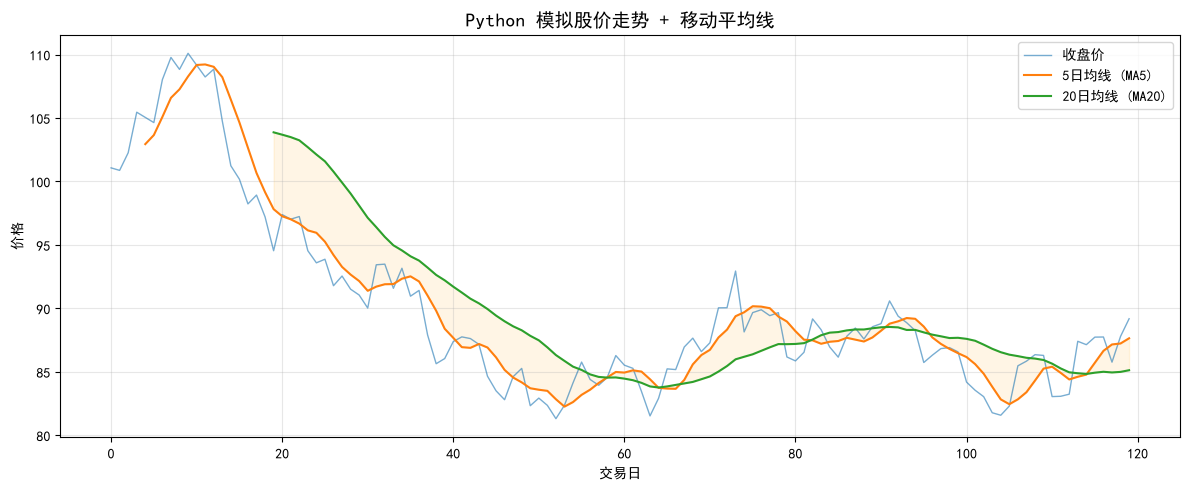

起始价格: ¥101.07
最终价格: ¥89.18
区间收益率: -11.76%
最大回撤价格: ¥81.31
最高价格: ¥110.10


In [1]:
# ========== 导入库 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import pandas as pd                      # 表格数据处理（像 Excel）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']      # 图表中文
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(42)          # 固定随机数，结果可复现
days = 120                  # 一共模拟 120 个交易日
daily_returns = np.random.normal(loc=0.0008, scale=0.02, size=days)  # 每天随机收益率
price = 100 * np.cumprod(1 + daily_returns)     # 从100元出发连乘成价格序列

df = pd.DataFrame({  # 构建表格
    '收盘价': price,                              # 原始模拟收盘价
    '5日均线': pd.Series(price).rolling(5).mean(),   # 最近5天均价
    '20日均线': pd.Series(price).rolling(20).mean()  # 最近20天均价
})  # 执行本行代码

plt.figure(figsize=(12, 5))                     # 创建画布，宽12高5英寸
plt.plot(df['收盘价'], label='收盘价', alpha=0.6, linewidth=1)  # 画折线图
plt.plot(df['5日均线'], label='5日均线 (MA5)', linewidth=1.5)  # 画折线图
plt.plot(df['20日均线'], label='20日均线 (MA20)', linewidth=1.5)  # 画折线图
plt.fill_between(range(days), df['5日均线'], df['20日均线'], alpha=0.1, color='orange')  # 两线之间浅色填充
plt.title('Python 模拟股价走势 + 移动平均线', fontsize=14)  # 设置图标题
plt.xlabel('交易日')                             # 横轴说明
plt.ylabel('价格')  # 设置纵轴标签
plt.legend()                                    # 图例
plt.grid(True, alpha=0.3)                       # 浅色网格，方便读数
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print(f"起始价格: ¥{price[0]:.2f}")              # 第一天价格
print(f"最终价格: ¥{price[-1]:.2f}")              # 最后一天价格
print(f"区间收益率: {(price[-1]/price[0] - 1)*100:.2f}%")  # 整段涨跌幅
print(f"最大回撤价格: ¥{price.min():.2f}")        # 期间最低价
print(f"最高价格: ¥{price.max():.2f}")            # 期间最高价
